**<font size="5">Applied Statistics</font>**

<font size="3">MSc in High Performance Computing Engineering, Computer Science and Engineering, Physics Engineering, ... cod 062102</font>

A.Y. 2025-2026

Prof. Michela Carlotta Massi - Dott. Vittorio Torri

---

<font size="4">**Lab 2 - Dimensionality Reduction**</font>

# Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
import time
from tqdm.notebook import tqdm

In [ ]:
plt.rcParams["figure.figsize"] = (8,8)

# PCA - Implementation and Theory

## Empirical Search for the Direction of Maximum Variance

Simulate bivariate normal data

In [ ]:
np.random.seed(5032024) # fix random seed for reproducible results
mu = np.array([1, 2]) # mean
sig = np.array([[1, 1], # cov matrix
                [1, 4]])
n = 100 # number of observations
X = np.random.multivariate_normal(mu, sig, n) # sample from multivariate normal N(mu,sig)
mean_X = X.mean(axis=0)

In [ ]:
mean_X

In [ ]:
X

Plot the data and the sample mean

In [ ]:
fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], color='black', marker='o') # plot the data
ax.scatter(mean_X[0], mean_X[1], color='red', s=50) # add a red point with the sample mean
ax.set_xlabel('Var 1')
ax.set_ylabel('Var 2')
ax.set_xlim(-6, 6)
ax.set_ylim(-5, 10)
ax.set_aspect('equal', adjustable='box')
plt.title('Bivariate Normal Data')

Compute the variance along specific directions

In [ ]:
# Compute and plot variance of the projection of the data along the x-axis
fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], color='black')
ax.axhline(mean_X[1], color='grey', linestyle='--')
ax.scatter(X[:,0], np.full(n, mean_X[1]), color='red') # project all points on x-axis
var_x = np.var(X[:,0], ddof=1) # ddof=1 computes the sample variance correctly (here variance on the x axis)
print('Variance along x-axis:', var_x)

In [ ]:
# Let's repeat for the y-axis
fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], color='black')
ax.axhline(mean_X[1], color='grey', linestyle='--')
ax.scatter(X[:,0], np.full(n, mean_X[1]), color='red')

ax.axvline(mean_X[0], color='grey', linestyle='--')
ax.scatter(np.full(n, mean_X[0]), X[:,1], color='blue')
var_y = np.var(X[:,1], ddof=1)
print('Variance along y-axis:', var_y)
plt.title('Variance along Coordinate Axes')

Projection along $\theta = \pi/6$

In [ ]:
theta = np.pi / 6
a = np.array([np.cos(theta), np.sin(theta)])

proj30 = (X - mean_X) @ a  # matrix multiplication for projection

fig, ax = plt.subplots()

# original points
ax.scatter(X[:,0], X[:,1], color='black')

# projection line
x_line = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1]+2, 100)
y_line = mean_X[1] - np.tan(theta)*mean_X[0] + np.tan(theta)*x_line
ax.plot(x_line, y_line, linestyle='--', color='black')

# projected points
X_proj = np.column_stack([
    mean_X[0] + np.cos(theta) * proj30,
    mean_X[1] + np.sin(theta) * proj30
])

ax.scatter(X_proj[:,0], X_proj[:,1], color='red')

# segments from original points to projections
for i in range(len(X)):
    ax.plot(
        [X[i,0], X_proj[i,0]],
        [X[i,1], X_proj[i,1]],
        linestyle='--',
        color='red',
        alpha=0.6
    )

ax.set_aspect('equal')

var_proj30 = np.var(proj30, ddof=1)
print('Variance along direction (pi/6):', var_proj30)

plt.title('Projection along theta = pi/6')
plt.show()

Compute variance along all directions, find min and max variance

In [ ]:
thetas = np.linspace(0, np.pi, 181)
variances = []
for t in thetas:
    a_t = np.array([np.cos(t), np.sin(t)])
    v = np.var(X @ a_t, ddof=1)
    variances.append(v)
variances = np.array(variances)
max_var = variances.max()
max_theta = thetas[variances.argmax()]
min_var = variances.min()
min_theta = thetas[variances.argmin()]

In [ ]:
max_theta / np.pi * 180

In [ ]:
min_theta / np.pi * 180

In [ ]:
max_var

In [ ]:
min_var

Plot variance along all directions, highlighting directions with min and max variance

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16,6))
axs[0].scatter(X[:,0], X[:,1], color='black', marker='.')
axs[0].plot(x_line, mean_X[1] - np.tan(max_theta)*mean_X[0] + np.tan(max_theta)*x_line,
            linestyle=':', color='red', linewidth=2)
axs[0].plot(x_line, mean_X[1] - np.tan(min_theta)*mean_X[0] + np.tan(min_theta)*x_line,
            linestyle=':', color='blue', linewidth=2)
axs[0].set_xlabel('Var 1')
axs[0].set_ylabel('Var 2')
axs[0].set_aspect('equal')

axs[1].plot(thetas, variances, color='darkgrey', linewidth=2)
axs[1].scatter([max_theta], [max_var], color='red')
axs[1].scatter([min_theta], [min_var], color='blue')
axs[1].axvline(max_theta, color='red', linestyle='--')
axs[1].axvline(min_theta, color='blue', linestyle='--')
axs[1].set_xlabel('Theta')
axs[1].set_ylabel('Variance')
plt.suptitle('Variance along All Directions')
plt.tight_layout()
plt.show()

## Comparison with the theory

PCA is obtained by computing the covariance matrix, its eigenvectors and eigenvalues

In [ ]:
M = mean_X  # sample mean from previous cell
S = np.cov(X, rowvar=False)
eigvals, eigvecs = np.linalg.eig(S)
order = eigvals.argsort()[::-1] #sort in descending order for eigenvalues
eigvals, eigvecs = eigvals[order], eigvecs[:, order]

print("Eigenvalues:", eigvals)
print("Eigenvectors (columns):\n", eigvecs)
print("Empirical max variance:", max_var)
print("Empirical min variance:", min_var)

max_a = np.array([np.cos(max_theta), np.sin(max_theta)])
min_a = np.array([np.cos(min_theta), np.sin(min_theta)])
print(f"Empirical max direction: {max_a} (theta={max_theta})")
print(f"Empirical min direction: {min_a} (theta={min_theta})")

In [ ]:
# Length for drawing lines
L = 4

fig, ax = plt.subplots(figsize=(12, 12))
ax.scatter(X[:, 0], X[:, 1], color="black", alpha=0.8)

# Empirical max direction
ax.plot(
    [M[0] - L * max_a[0], M[0] + L * max_a[0]],
    [M[1] - L * max_a[1], M[1] + L * max_a[1]],
    '--', lw=2, label='Empirical max direction', color='red'
)

# Empirical min direction
ax.plot(
    [M[0] - L * min_a[0], M[0] + L * min_a[0]],
    [M[1] - L * min_a[1], M[1] + L * min_a[1]],
    '--', lw=2, label='Empirical min direction', color='orange'
)

# Eigenvectors
v1 = eigvecs[:, 0].copy()
v2 = eigvecs[:, 1].copy()

# Align signs for easier visual comparison
if np.dot(v1, max_a) < 0:
    v1 = -v1
if np.dot(v2, min_a) < 0:
    v2 = -v2

# First eigenvector
ax.plot(
    [M[0] - L * v1[0], M[0] + L * v1[0]],
    [M[1] - L * v1[1], M[1] + L * v1[1]],
    '-', lw=2, label='1st eigenvector', alpha=0.6, color='blue'
)

# Second eigenvector
ax.plot(
    [M[0] - L * v2[0], M[0] + L * v2[0]],
    [M[1] - L * v2[1], M[1] + L * v2[1]],
    '-', lw=2, label='2nd eigenvector', alpha=0.6, color='green'
)

ax.scatter(M[0], M[1], s=80, marker='x', label='Mean')

ax.set_title("Empirical directions vs covariance eigenvectors")
ax.set_aspect("equal")
ax.legend()
plt.show()

# PCA Example - Tourists Dataset

## Load and visualize dataset

The dataset "tourists.txt" collects the data on the flow of Italian tourism
from outside Lombardy to Milan for the year 2015. Each statistical unit
corresponds to a Region of origin and a month of observation. For each unit,
the tourist flow is quantified through the number of nights spent by clients
in: '5 stars hotels', '4 stars hotels', '3 stars hotels', '2 stars hotels',
'1 star hotels', 'residences', 'B&B' and 'rented flats'.

In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

In [ ]:
import os
os.chdir('/content/drive/MyDrive/_Polimi/StatAppHPC')

In [ ]:
# Read the tourists dataset
tourists = pd.read_csv('tourists.txt', sep=' ')
print(tourists.head())

In [ ]:
tourists_data = tourists.iloc[:, 2:]
tourists_label = tourists.iloc[:, :2]
n_tour, p_tour = tourists_data.shape
print('Tourists dataset shape:', tourists_data.shape)

Boxplot of original data

In [ ]:
plt.figure()
tourists_data.boxplot(rot=90, grid=False)
plt.title('Tourists Data (Original)')
plt.show()

PCA is not about the mean, it is about the variability

In [ ]:
tourists_centered = tourists_data - tourists_data.mean()

ax = tourists_centered.boxplot(rot=90, grid=False)
plt.title('Centered Tourists Data')
plt.show()

## PCA on original data

In [ ]:
pca_tourists = PCA()
tourists_scores = pca_tourists.fit_transform(tourists_data)
print('Tourists PCA explained variance ratio:\n', pca_tourists.explained_variance_ratio_)

In [ ]:
pc_sd = np.sqrt(pca_tourists.explained_variance_)
print("Standard deviation of the components:")
print(pc_sd)

# Cumulative proportion of explained variance:
cumulative_explained_variance = np.cumsum(pca_tourists.explained_variance_ratio_)
print("Cumulative proportion of explained variance:")
print(cumulative_explained_variance)

Loadings, i.e. composition of PCs

In [ ]:
load_tour = pca_tourists.components_.T
load_tour

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(8, 12))

for i, ax in enumerate(axes):
    ax.bar(tourists_data.columns, load_tour[:, i])
    ax.set_xticklabels(tourists_data.columns, rotation=90)
    ax.set_ylabel(f"PC{i+1} Loading")
    ax.set_title(f"Loadings for PC{i+1}")

plt.tight_layout()
plt.show()


Interpretation of the loadings:

First PC: weighted average of the number of nights in 3,4 stars hotel and residences

Second PC: contrast between the number of nights in 3 and 4 stars hotel

Third PC: residences

The loadings reflect the previous observation: the first 3 PCs are
driven by the variables displaying the highest variability

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].plot(np.arange(1, p_tour+1), pca_tourists.explained_variance_, marker='o')
axs[0].set_title('PC Variances (Scree plot)')
orig_variances = tourists_data.var(ddof=1)
axs[1].bar(tourists_data.columns, orig_variances)
axs[1].tick_params(axis='x', rotation=45)
plt.setp(axs[1].get_xticklabels(), rotation=45, ha='right')
axs[1].set_title('Original Variables Variance')
cum_explained = np.cumsum(pca_tourists.explained_variance_ratio_)
axs[2].plot(np.arange(1, p_tour+1), cum_explained, marker='o')
axs[2].axhline(1, color='blue')
axs[2].axhline(0.8, color='blue', linestyle='--')
axs[2].set_xlabel('Number of components')
axs[2].set_ylabel('Cumulative explained variance')
axs[2].set_ylim(0,1)
plt.tight_layout()
plt.show()

The first PC explains more than 98% of the total variability.

This is due to the masking effect of those 3 variables over the others

## PCA on standardized data

Data standardization is always recommended before doing PCA

$$
Z = \frac{X - \mu}{\sigma}
$$

In [ ]:
scaler = StandardScaler()
tourists_std = scaler.fit_transform(tourists_data)
tourists_std_df = pd.DataFrame(tourists_std, columns=tourists_data.columns)
plt.figure()
tourists_std_df.boxplot(rot=90, grid=False)
plt.title('Tourists Data (Standardized)')
plt.show()

PCA on standardized data

In [ ]:
pca_tourists_std = PCA()
tourists_scores_std = pca_tourists_std.fit_transform(tourists_std_df)
print('Standardized Tourists PCA explained variance ratio:\n', pca_tourists_std.explained_variance_ratio_)
load_tour_std = pca_tourists_std.components_.T

In [ ]:
pc_sd = np.sqrt(pca_tourists_std.explained_variance_)
print("Standard deviation of the components:")
print(pc_sd)

cumulative_explained_variance = np.cumsum(pca_tourists_std.explained_variance_ratio_)
print("Cumulative proportion of explained variance:")
print(cumulative_explained_variance)

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].plot(np.arange(1, p_tour+1), pca_tourists_std.explained_variance_, marker='o')
axs[0].set_title('PC Variances')
orig_variances = tourists_std_df.var(ddof=1)
axs[1].bar(tourists_data.columns, orig_variances)
axs[1].tick_params(axis='x', rotation=45)
plt.setp(axs[1].get_xticklabels(), rotation=45, ha='right')
axs[1].set_title('Original Variables Variance')
cum_explained = np.cumsum(pca_tourists_std.explained_variance_ratio_)
axs[2].plot(np.arange(1, p_tour+1), cum_explained, marker='o')
axs[2].axhline(1, color='blue')
axs[2].axhline(0.8, color='blue', linestyle='--')
axs[2].set_xlabel('Number of components')
axs[2].set_ylabel('Cumulative explained variance')
axs[2].set_ylim(0,1)
plt.tight_layout()
plt.show()

If we wanted to perform dimensionality reduction, we could keep 1 or 2 PCs

Loadings

In [ ]:
load_tour_std = pca_tourists_std.components_.T
load_tour_std

In [ ]:
# Barplots of loadings for the first three PCs
fig, axs = plt.subplots(3, 1, figsize=(8,12))
for i in range(3):
    axs[i].bar(tourists_std_df.columns, load_tour_std[:, i])
    axs[i].set_ylim([-1, 1])
    axs[i].set_title(f'Loadings PC {i+1}')
    axs[i].tick_params(axis='x', rotation=45)
    plt.setp(axs[i].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

Interpretation of the loadings:

In this case, the first PC represents an average of the number of nights spent in all the types of hotels and residences, taken with very similar weights.
The second PC contrasts the more expensive solutions (4,5 stars hotels and residences) against the cheap solutions (1,2 stars hotels and B&B), while the third focuses on B&B

High PC1: general high flow of tourists
Low PC1: general low flow of tourists
High PC2: high flow for expensive solutions, low flow for cheap solutions
Low PC2: low flow for expensive solutions, high flow for cheap solutions


## Interpretations with categorical variables

Project the data applying PCA

In [ ]:
scores_tourists = pca_tourists_std.transform(tourists_std_df)
n = scores_tourists.shape[0]

# Scatter plot of the scores for the first two PCs
plt.figure(figsize=(6,6))
plt.scatter(scores_tourists[:, 0], scores_tourists[:, 1], color='black', marker='o')
plt.axhline(0, linestyle='--', color='grey')
plt.axvline(0, linestyle='--', color='grey')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Scatter Plot of PCA Scores (PC1 vs PC2)")
plt.show()

Analysis by month

In [ ]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sept", "Oct", "Nov", "Dec"]

# Convert the first column to an ordered categorical variable.
tourists_label['Month'] = pd.Categorical(tourists_label.iloc[:, 0],
                                           categories=months,
                                           ordered=True)

# Define a cyclic palette (list of hex colors) for the 12 months.
palette = ["#2D1857", "#4D2C8C", "#6C47C7", "#8B63FF", "#7A8CDD", "#68B5C5",
           "#5ECABA", "#46AF89", "#108963", "#047138", "#025A26", "#013814"]

# Map each month to a color.
month_to_color = {m: c for m, c in zip(months, palette)}
col_lab1 = tourists_label['Month'].map(month_to_color)


In [ ]:
# Scatter plot of scores colored by month.
plt.figure(figsize=(8,6))
plt.scatter(scores_tourists[:, 0], scores_tourists[:, 1], c=col_lab1, marker='o')
plt.axhline(-3, color='black')
plt.axvline(-8, color='black')
# Additional points along the margins
plt.scatter(scores_tourists[:, 0], np.full(n, -3), c=col_lab1, marker='o')
plt.scatter(np.full(n, -8), scores_tourists[:, 1], c=col_lab1, marker='o')
plt.axhline(0, linestyle='--', color='grey')
plt.axvline(0, linestyle='--', color='grey')
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Scores Colored by Month")

legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=month_to_color[m],
                               markersize=8, label=m) for m in months]
plt.legend(handles=legend_handles, title="Month", loc='upper right')
plt.show()

Analysis for month of Expo (May to Oct)

In [ ]:
expo_months = ["May", "Jun", "Jul", "Aug", "Sept", "Oct"]

# Create a new column 'Expo' that is 'Expo' if the month is in expo_months, otherwise 'Non Expo'
tourists_label['Expo'] = tourists_label['Month'].apply(lambda m: 'Expo' if m in expo_months else 'Non Expo')

# Define colors for Expo groups.
col_expo = tourists_label['Expo'].map({'Expo': 'red', 'Non Expo': 'blue'})

# Create a layout with a scatter plot and two boxplots.
import matplotlib.gridspec as gridspec
fig = plt.figure(constrained_layout=True, figsize=(10,8))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 4], height_ratios=[4, 1])

ax_scatter = fig.add_subplot(gs[0, 1])
ax_box_y = fig.add_subplot(gs[0, 0], sharey=ax_scatter)
ax_box_x = fig.add_subplot(gs[1, 1], sharex=ax_scatter)

# Scatter plot with expo colors.
ax_scatter.scatter(scores_tourists[:, 0], scores_tourists[:, 1], c=col_expo, marker='o')
ax_scatter.set_xlim(-8.5, 20)
ax_scatter.set_ylim(-3.2, 3.2)
ax_scatter.axhline(-3, color='black')
ax_scatter.axvline(-8, color='black')
ax_scatter.scatter(scores_tourists[:, 0], np.full(n, -3), c=col_expo, marker='o')
ax_scatter.scatter(np.full(n, -8), scores_tourists[:, 1], c=col_expo, marker='o')
ax_scatter.axhline(0, linestyle='--', color='grey')
ax_scatter.axvline(0, linestyle='--', color='grey')
ax_scatter.set_xlabel("PC1")
ax_scatter.set_ylabel("PC2")
ax_scatter.set_title("Scores Colored by Expo")

# Prepare a DataFrame for boxplots.
scores_df = pd.DataFrame(scores_tourists[:,:2], columns=["PC1", "PC2"])
scores_df['Expo'] = tourists_label['Expo']

# Boxplot for PC2 grouped by Expo (vertical boxplot)
sns.boxplot(x='Expo', y='PC2', data=scores_df, ax=ax_box_y,
            palette={'Expo': 'red', 'Non Expo': 'blue'})
ax_box_y.set_ylim(-3.2, 3.2)
ax_box_y.tick_params(axis='x', rotation=45)

# Boxplot for PC1 grouped by Expo (horizontal boxplot)
sns.boxplot(x='PC1', y='Expo', data=scores_df, ax=ax_box_x,
            palette={'Expo': 'red', 'Non Expo': 'blue'}, orient='h')
ax_box_x.set_xlim(-8.5, 20)
ax_box_x.tick_params(axis='y', rotation=45)

plt.show()


Scores Colored by Region of Origin

In [ ]:
regions = tourists_label['Region.of.origin'].unique()
# Create a color mapping using a rainbow colormap.
region_colors = {region: color for region, color in zip(regions, plt.cm.rainbow(np.linspace(0, 1, len(regions))))}
col_lab2 = tourists_label.iloc[:, 1].map(region_colors)

plt.figure(figsize=(8,6))
plt.scatter(scores_tourists[:, 0], scores_tourists[:, 1], c=col_lab2, marker='o')
plt.xlim(-8.5, 30)
plt.ylim(-3.2, 3.2)
plt.axhline(-3, color='black')
plt.axvline(-8, color='black')
plt.scatter(scores_tourists[:, 0], np.full(n, -3), c=col_lab2, marker='o')
plt.scatter(np.full(n, -8), scores_tourists[:, 1], c=col_lab2, marker='o')
plt.axhline(0, linestyle='--', color='grey')
plt.axvline(0, linestyle='--', color='grey')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Scores Colored by Region of Origin")
# Create legend for regions.
legend_handles_regions = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=region_colors[r],
                                     markersize=8, label=r) for r in regions]
plt.legend(handles=legend_handles_regions, title="Region", loc='upper right')
plt.show()

# t-SNE & UMAP - Genomic dataset

## Load data

In [ ]:
# Cells in rows, genes in columns
expression_data = pd.read_csv("expression.csv", index_col=0)
# Classes
meta_data = pd.read_csv("meta.csv", index_col=0)

In [ ]:
expression_data

In [ ]:
meta_data

## PCA

Let's run a PCA first

In [ ]:
labels = pd.factorize(meta_data["cell_type"])[0] # convert to int labels

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(expression_data)

ev = pca.explained_variance_ratio_

print(f"Explained variance PC1: {ev[0]:.3f}")
print(f"Explained variance PC2: {ev[1]:.3f}")
print(f"Total (PC1 + PC2): {(ev[0]+ev[1]):.3f}")

# Plot PCA projection
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap="tab10", s=20)

plt.xlabel(f"PC1 ({ev[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({ev[1]*100:.1f}% variance)")
plt.title("PCA of gene expression data")

plt.tight_layout()
plt.show()

## t-SNE

In [ ]:
from sklearn.manifold import TSNE

# t-SNE directly on original data
tsne_raw = TSNE(
    n_components=2,
    perplexity=100,
    init="random",
    learning_rate="auto",
    random_state=42,
    max_iter=1000
)
start = time.time()
X_tsne_raw = tsne_raw.fit_transform(expression_data)
end = time.time()

print(f"t-SNE without PCA runtime: {end - start:.2f} seconds")

# PCA + t-SNE
pca = PCA(n_components=50, random_state=42)
X_pca50 = pca.fit_transform(expression_data)

tsne_pca = TSNE(
    n_components=2,
    perplexity=100,
    #init='pca',
    learning_rate="auto",
    random_state=42,
    max_iter=1000
)

start = time.time()
X_tsne_pca = tsne_pca.fit_transform(X_pca50)
end = time.time()
print(f"t-SNE with PCA runtime: {end - start:.2f} seconds")


# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_tsne_raw[:, 0], X_tsne_raw[:, 1], c=labels, cmap="tab10", s=20)
axes[0].set_title("t-SNE on original data")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")

axes[1].scatter(X_tsne_pca[:, 0], X_tsne_pca[:, 1], c=labels, cmap="tab10", s=20)
axes[1].set_title("t-SNE after PCA")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

We can explore different values of perplexity. Be aware that the following cell takes several minutes to be executed

In [ ]:
perplexities = [10, 30, 50, 80, 100, 150]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for ax, p in tqdm(zip(axes, perplexities), total=len(perplexities)):
    Y = TSNE(
        n_components=2,
        perplexity=p,
        init="pca",
        learning_rate="auto",
        random_state=42,
        max_iter=1000
    ).fit_transform(X_pca50)

    ax.scatter(Y[:, 0], Y[:, 1], c=labels, cmap="tab10", s=10)
    ax.set_title(f"perplexity={p}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

Perplexity controls the scale of neighborhoods used by t-SNE.
Small values emphasize very local relationships, often producing fragmented embeddings, while large values emphasize global structure but may blur cluster boundaries.

## UMAP

In [ ]:
!pip install umap-learn

In [ ]:
import umap.umap_ as umap

# UMAP on original data
start = time.time()

X_umap_raw = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
).fit_transform(expression_data)

end = time.time()
print(f"UMAP without PCA runtime: {end - start:.2f} seconds")


# PCA + UMAP
X_pca50 = PCA(n_components=50, random_state=42).fit_transform(expression_data)

start = time.time()

X_umap_pca = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
).fit_transform(X_pca50)

end = time.time()
print(f"UMAP with PCA runtime: {end - start:.2f} seconds")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_umap_raw[:, 0], X_umap_raw[:, 1], c=labels, cmap="tab10", s=20)
axes[0].set_title("UMAP on original data")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

axes[1].scatter(X_umap_pca[:, 0], X_umap_pca[:, 1], c=labels, cmap="tab10", s=20)
axes[1].set_title("UMAP after PCA")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

plt.tight_layout()
plt.show()

We can explore different values for min_dist and n_neighbours. Again, the following cell can take several minutes to complete execution

In [ ]:
neighbors_list = [5, 10, 15, 30]
min_dist_list = [0.01, 0.1, 0.3]

fig, axes = plt.subplots(len(neighbors_list), len(min_dist_list),
                         figsize=(12,10))

for i, n in tqdm(enumerate(neighbors_list), total=len(neighbors_list)):
    for j, d in tqdm(enumerate(min_dist_list), total=len(min_dist_list)):

        embedding = umap.UMAP(
            n_neighbors=n,
            min_dist=d,
            n_components=2,
            random_state=42
        ).fit_transform(X_pca50)

        ax = axes[i, j]
        ax.scatter(embedding[:,0], embedding[:,1],
                   c=labels, cmap="tab10", s=10)

        ax.set_title(f"n_neigh={n}, min_dist={d}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

# Supplementary

## 3D PCA Visualization

The next cells simulate 3D data, plot the data and a covariance ellipsoid, and then show how the PCA approximates the data by 0D (a point), 1D (a line) and 2D (a plane) representations.

In [ ]:
# Simulate 3D data
mu3 = np.array([0, 2, 3])
sig3 = np.array([[9, 1, 1],
                 [1, 4, 1],
                 [1, 1, 1]])
nobs = 100
X3 = np.random.multivariate_normal(mu3, sig3, nobs)
M3 = X3.mean(axis=0)
S3 = np.cov(X3, rowvar=False)
print('3D sample mean:', M3)
print('3D sample covariance:\n', S3)

In [ ]:
# 3D plot of data
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X3[:,0], X3[:,1], X3[:,2], s=20)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title('3D Data')
plt.show()

In [ ]:
pca3 = PCA()
PC_scores = pca3.fit_transform(X3)
print('3D PCA components:\n', pca3.components_)
print('3D PCA explained variance:', pca3.explained_variance_)

In [ ]:
# 0-dimensional approximation: projection to the mean
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X3[:,0], X3[:,1], X3[:,2], s=20)
ax.scatter(M3[0], M3[1], M3[2], color='red', s=50)
for i in range(nobs):
    ax.plot([X3[i,0], M3[0]], [X3[i,1], M3[1]], [X3[i,2], M3[2]], color='blue', linewidth=0.5)
ax.set_title('0 PCs: Projection to a Point')
plt.show()

In [ ]:
# 1D approximation: projection on first principal component
explained_std = np.sqrt(pca3.explained_variance_)
PC1 = np.array([M3 + score[0] * pca3.components_[0] for score in PC_scores])
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X3[:,0], X3[:,1], X3[:,2], s=20)
ax.scatter(PC1[:,0], PC1[:,1], PC1[:,2], color='red', s=50)
for i in range(nobs):
    ax.plot([X3[i,0], PC1[i,0]], [X3[i,1], PC1[i,1]], [X3[i,2], PC1[i,2]], color='blue', linewidth=0.5)
line_PC1 = np.array([M3 + 2*explained_std[0]*pca3.components_[0],
                     M3 - 2*explained_std[0]*pca3.components_[0]])
ax.plot(line_PC1[:,0], line_PC1[:,1], line_PC1[:,2], color='forestgreen', linewidth=2)
ax.set_title('1 PC: Best Line Approximation')
plt.show()

In [ ]:
# 2D approximation: projection on first two principal components
PC12 = np.array([M3 + score[0]*pca3.components_[0] + score[1]*pca3.components_[1] for score in PC_scores])
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X3[:,0], X3[:,1], X3[:,2], s=20)
ax.scatter(PC12[:,0], PC12[:,1], PC12[:,2], color='red', s=50)
for i in range(nobs):
    ax.plot([X3[i,0], PC12[i,0]], [X3[i,1], PC12[i,1]], [X3[i,2], PC12[i,2]], color='blue', linewidth=0.5)
line_PC1 = np.array([M3 + 2*explained_std[0]*pca3.components_[0], M3 - 2*explained_std[0]*pca3.components_[0]])
line_PC2 = np.array([M3 + 2*explained_std[1]*pca3.components_[1], M3 - 2*explained_std[1]*pca3.components_[1]])
ax.plot(line_PC1[:,0], line_PC1[:,1], line_PC1[:,2], color='forestgreen', linewidth=2)
ax.plot(line_PC2[:,0], line_PC2[:,1], line_PC2[:,2], color='forestgreen', linewidth=2)
ax.set_title('2 PCs: Best Plane Approximation')
plt.show()

In [ ]:
# ## Space spanned by all PCs -------------------------------------------------------------------
# I, II and III principal components: the best approximation of dimension 3 (the entire space)

# Reconstruct each observation using all three PCs.
# This reconstruction should be (almost) identical to the original data.
PC123 = np.array([
    M3 + score[0]*pca3.components_[0] + score[1]*pca3.components_[1] + score[2]*pca3.components_[2]
    for score in PC_scores
])

# Create a 3D figure for the full reconstruction.
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the original 3D data points.
ax.scatter(X3[:, 0], X3[:, 1], X3[:, 2], s=20, label='Original Data')

# Plot the reconstructed data points (should closely overlay the original points).
ax.scatter(PC123[:, 0], PC123[:, 1], PC123[:, 2], color='red', s=50, label='Reconstructed Data')

# Draw blue lines connecting each original point with its reconstruction.
for i in range(nobs):
    ax.plot([X3[i, 0], PC123[i, 0]],
            [X3[i, 1], PC123[i, 1]],
            [X3[i, 2], PC123[i, 2]],
            color='blue', linewidth=0.5)

# For consistency with the 1D and 2D projection codes,
# we plot the principal component directions scaled by 2*standard deviation.
# (Here, we assume that 'explained_std' was computed as:
#     explained_std = np.sqrt(pca3.explained_variance_))
line_PC1 = np.array([M3 + 2 * explained_std[0] * pca3.components_[0],
                     M3 - 2 * explained_std[0] * pca3.components_[0]])
line_PC2 = np.array([M3 + 2 * explained_std[1] * pca3.components_[1],
                     M3 - 2 * explained_std[1] * pca3.components_[1]])
line_PC3 = np.array([M3 + 2 * explained_std[2] * pca3.components_[2],
                     M3 - 2 * explained_std[2] * pca3.components_[2]])

# Plot the principal component directions.
ax.plot(line_PC1[:, 0], line_PC1[:, 1], line_PC1[:, 2],
        color='forestgreen', linewidth=2, label='PC1')
ax.plot(line_PC2[:, 0], line_PC2[:, 1], line_PC2[:, 2],
        color='forestgreen', linewidth=2, label='PC2')
ax.plot(line_PC3[:, 0], line_PC3[:, 1], line_PC3[:, 2],
        color='forestgreen', linewidth=2, label='PC3')

ax.set_title("3 PCs: Full 3D Reconstruction (Entire Space)")
ax.legend()

plt.show()

## PCA on the Food Dataset

### Load and visualize dataset

In [ ]:
food = pd.read_csv('Food.txt', sep=' ')
print(food.head())
print('Food dataset shape:', food.shape)

In [ ]:
food.sum(axis=1)

In [ ]:
n_food, p_food = food.shape

food.boxplot(rot=90, grid=False)
plt.title('Food Dataset - Original')
plt.show()

In [ ]:
food_centered = food - food.mean()
plt.figure()
food_centered.boxplot(rot=90, grid=False)
plt.title('Food Dataset - Centered')
plt.show()

### PCA on standardized data

In [ ]:
### Standardize the food data

In [ ]:
# Standardize the food data - SOLUTION
scaler_food = StandardScaler()
food_std = scaler_food.fit_transform(food)
food_std_df = pd.DataFrame(food_std, columns=food.columns)
print(food_std_df.head())

In [ ]:
### Run PCA

In [ ]:
### Run PCA - SOLUTIONS
pca_food = PCA()
food_scores = pca_food.fit_transform(food_std_df)
print('Food PCA explained variance ratio:\n', pca_food.explained_variance_ratio_)

In [ ]:
### Plot PCs variances, original variables variances, scree plot

In [ ]:
### Plot PCs variances, original variables variances, scree plot
### SOLUTIONS
fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].plot(np.arange(1, p_food+1), pca_food.explained_variance_, marker='o')
axs[0].set_title('PC Variances')
orig_variances = food_std.var(ddof=1)
axs[1].bar(food_std_df.columns, orig_variances)
axs[1].tick_params(axis='x', rotation=45)
plt.setp(axs[1].get_xticklabels(), rotation=45, ha='right')
axs[1].set_title('Original Variables Variance')
cum_explained = np.cumsum(pca_food.explained_variance_ratio_)
axs[2].plot(np.arange(1, p_food+1), cum_explained, marker='o')
axs[2].axhline(1, color='blue')
axs[2].axhline(0.8, color='blue', linestyle='--')
axs[2].set_xlabel('Number of components')
axs[2].set_ylabel('Cumulative explained variance')
axs[2].set_ylim(0,1)
plt.tight_layout()
plt.show()

In [ ]:
### Plot loadings for all PCs

In [ ]:
### Plot loadings for all PCs - SOLUTIONS

In [ ]:
scores_food_df = pd.DataFrame(food_scores)

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# Boxplot for the original variables
bp1 = axs[0].boxplot(food_std_df.values, patch_artist=True)
# Set x-tick labels using the DataFrame's column names and rotate them 90° (or 45° if desired)
axs[0].set_xticklabels(food_std_df.columns, rotation=90)  # change rotation=45 if you prefer
axs[0].set_title('Original Variables')
# Color each box gold
for box in bp1['boxes']:
    box.set_facecolor('gold')

# Boxplot for the PCA scores (principal components)
bp2 = axs[1].boxplot(scores_food_df.values, patch_artist=True)
axs[1].set_xticklabels(scores_food_df.columns, rotation=90)  # or rotation=45 as needed
axs[1].set_title('Principal Components')
for box in bp2['boxes']:
    box.set_facecolor('gold')

plt.tight_layout()
plt.show()

In [ ]:
load_food = pca_food.components_.T
fig, axs = plt.subplots(4, 1, figsize=(8,12))
for i in range(4):
    axs[i].bar(food_std_df.columns, load_food[:, i])
    axs[i].set_ylim([-1, 1])
    axs[i].set_title(f'Loadings Food PC {i+1}')
plt.tight_layout()
plt.show()

In [ ]:
# with only the most significant loadings
fig, axs = plt.subplots(4, 1, figsize=(8, 12))
for i in range(4):
    # Replace values with 0 if |value| < 0.3
    significant_loadings = np.where(np.abs(load_food[:, i]) < 0.3, 0, load_food[:, i])
    axs[i].bar(food_std_df.columns, significant_loadings)
    axs[i].set_ylim([-1, 1])
    axs[i].axhline(0, color='black', linewidth=1)
    axs[i].set_title(f'Loadings PC {i+1}')
plt.tight_layout()
plt.show()


Let's have a look at how well we can reconstruct the original data with an increasing number of components

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n_obs, n_vars = food_std_df.shape
x = np.arange(n_vars)  # x-axis: one value for each variable (or use food_sd.columns if preferred)

# Create a figure with 2 rows and 5 columns (10 subplots total)
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
axs = axs.flatten()  # Flatten for easy iteration

# --- Plot the Original Data ---
# Each observation (each row of food_sd) is plotted as a line.
for i in range(n_obs):
    axs[0].plot(x, food_std_df.iloc[i, :], '--', alpha=0.7)
axs[0].set_title("Data")
axs[0].set_ylim(food_std_df.values.min(), food_std_df.values.max())

# --- Plot the "First 0 PCs" Approximation ---
# Compute the mean vector (i.e. the column means) of food_sd.
meanF = food_std_df.mean(axis=0).values

# Create an initial projection matrix that is just the mean for every observation.
projection = np.tile(meanF, (n_obs, 1))
for i in range(n_obs):
    axs[1].plot(x, projection[i, :], '--', color='black', alpha=0.7)
# Overlay the overall mean as a thick black line.
axs[1].plot(x, meanF, 'k-', linewidth=2)
axs[1].set_title("First 0 PCs")
axs[1].set_ylim(food_std_df.values.min(), food_std_df.values.max())

# --- Iteratively Add the Contributions of the First k PCs ---
# For each component from 1 to 8 (or fewer if there are not 8 PCs),
# update the projection by adding the outer product of the PC scores and its loading.
num_components = min(8, scores_food_df.shape[1])
for comp in range(num_components):
    # Update: for the comp-th PC, add (score for that PC) * (loading vector for that PC)
    # This yields an (n_obs x n_vars) matrix.
    projection = projection + np.outer(scores_food_df.iloc[:, comp], load_food[:, comp])

    # Plot the updated projection in subplot comp+2 (since index 0 is original data, index 1 is 0 PCs).
    ax = axs[comp + 2]
    # Plot one line per observation (i.e. each row of projection)
    for i in range(n_obs):
        ax.plot(x, projection[i, :], '--', alpha=0.7)
    # Optionally overlay the mean for reference.
    ax.plot(x, meanF, 'k-', linewidth=2)
    ax.set_title(f"First {comp+1} PCs")
    ax.set_ylim(food_std_df.values.min(), food_std_df.values.max())

plt.tight_layout()
plt.show()


In the first plot each line corresponds to an observation of the original dataset

In the second plot there are no principal components: each observation is represented by the mean, which is zero for all since they were standardized

From the third plot on we progressively add more principal components

## t-SNE and UMAP on digits dataset

Let's load a default dataset of 8x8 images depicting digits

In [ ]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data
y = digits.target


In [ ]:
X.shape

In [ ]:
### Compare 2D PCA, t-SNE and UMAP

You should get something like this:

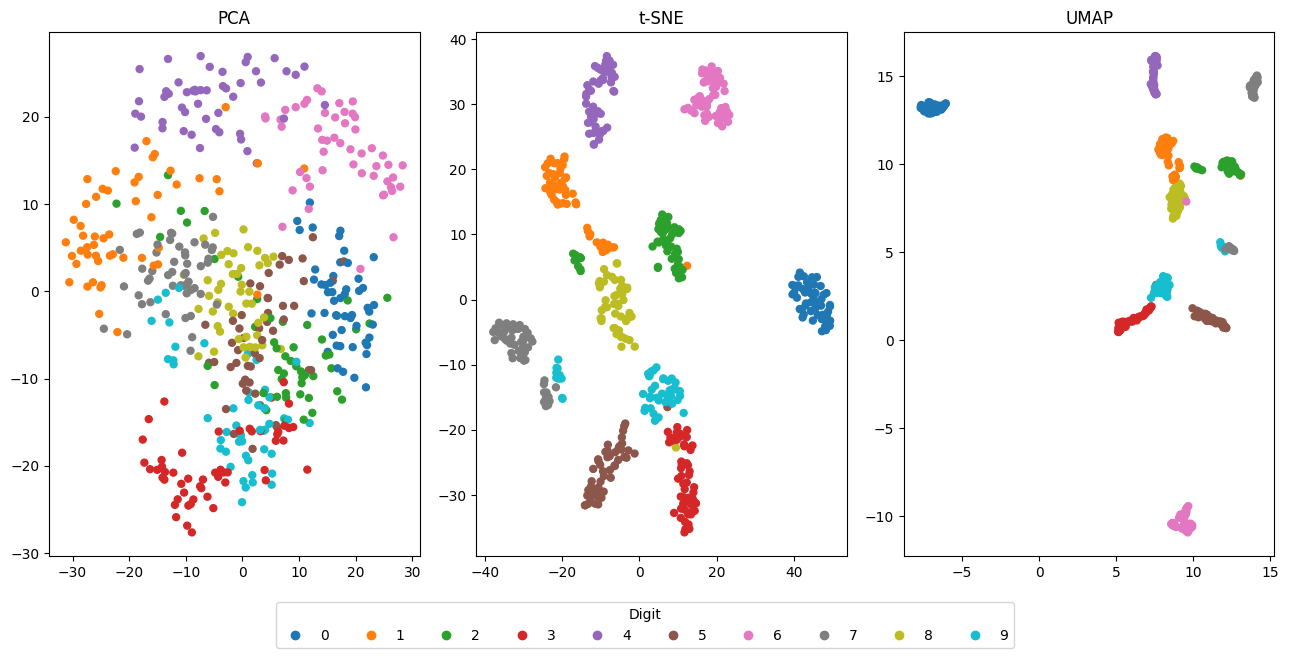

In [ ]:
# SOLUTIONS

import umap.umap_ as umap
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Use only first 500 samples
# X = X[:500]
# y = y[:500]

# PCA
X_pca = PCA(n_components=2, random_state=42).fit_transform(X)

# t-SNE
X_tsne = TSNE(
    n_components=2,
    perplexity=20,
    random_state=42,
    learning_rate="auto",
    max_iter=1000
).fit_transform(X)

# UMAP
X_umap = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
).fit_transform(X)

# Plot comparison
fig, axes = plt.subplots(1,3, figsize=(13,6))

sc1 = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="tab10", s=25)
axes[0].set_title("PCA")

axes[1].scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap="tab10", s=25)
axes[1].set_title("t-SNE")

axes[2].scatter(X_umap[:,0], X_umap[:,1], c=y, cmap="tab10", s=25)
axes[2].set_title("UMAP")

# Common legend below the plots
handles, labels = sc1.legend_elements(num=10)

fig.legend(
    handles,
    [str(i) for i in range(10)],
    title="Digit",
    loc="lower center",
    ncol=10,
    bbox_to_anchor=(0.5, -0.10)
)

plt.tight_layout()
plt.show()

# Feedback

Please leave a feedback on this lab through [this form](https://forms.office.com/e/HSgSw9Uvjk) (estimated 2 minutes)